# TAO velocity comparison (0N, 140W), Oct-Dec 2012: dt300 vs dt60 vs obs

Model equivalents are the online pkg/profiles output (`prof_Uestim/Vestim`) in each
run's `PROF_eq/TAO_WO_2012_ADCP_v2_model.nc`; observations (`prof_U/V`) are identical
across files. Comparison period is Oct-Dec 2012 (both runs are now ~3 months).
Profiles are daily-averaged onto the TAO depth grid.

In [1]:
import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import cmocean.cm as cmo
import warnings
warnings.filterwarnings('ignore')

# save each figure to figures/ (in creation order) and display it
os.makedirs('figures', exist_ok=True)
_fig_i = [0]
def show(prefix='tao'):
    plt.savefig(f'figures/{prefix}_{_fig_i[0]:02d}.png', dpi=120, bbox_inches='tight')
    _fig_i[0] += 1
    plt.show()

RUNS = {'dt300': '/data/SO3/edavenport/tpose24/oct2012_3mo_dt300_AB3/PROF_eq/TAO_WO_2012_ADCP_v2_model.nc',
        'dt60':  '/data/SO3/edavenport/tpose24/oct2012_3mo_dt60_AB3/PROF_eq/TAO_WO_2012_ADCP_v2_model.nc'}
COL = {'dt300': 'tab:blue', 'dt60': 'tab:red'}
TARGET_LON = -140.0
PERIOD = ('2012-10-01', '2012-12-29')

In [2]:
def parse_dt(yyyymmdd, hhmmss):
    d, t = int(yyyymmdd), int(hhmmss)
    return pd.Timestamp(d//10000, (d%10000)//100, d%100, t//10000, (t%10000)//100, t%100)

def load_run(path):
    ds = xr.open_dataset(path)
    lon = ds['prof_lon'].values
    depths = ds['prof_depth'].values
    ts = np.array([parse_dt(a, b) for a, b in zip(ds['prof_YYYYMMDD'].values, ds['prof_HHMMSS'].values)])
    m = (lon == TARGET_LON)
    U, V = ds['prof_U'].values.astype(float), ds['prof_V'].values.astype(float)
    Ue, Ve = ds['prof_Uestim'].values.astype(float), ds['prof_Vestim'].values.astype(float)
    return ts[m], depths, U[m], V[m], Ue[m], Ve[m]

def daily(arr, day_idx, days):
    out = np.full((len(days), arr.shape[1]), np.nan)
    for i, d in enumerate(days):
        sel = day_idx == d
        if sel.any():
            out[i] = np.nanmean(arr[sel], axis=0)
    return out

days = pd.date_range(PERIOD[0], PERIOD[1], freq='D')
obs = {}
model = {}
for r, p in RUNS.items():
    ts, depths, U, V, Ue, Ve = load_run(p)
    di = pd.DatetimeIndex(ts).normalize()
    obs['U'], obs['V'] = daily(U, di, days), daily(V, di, days)   # identical across runs
    model[r] = {'U': daily(Ue, di, days), 'V': daily(Ve, di, days)}
Z = -depths
print('depth levels', len(depths), f'({depths[0]:.0f}-{depths[-1]:.0f} m)  days {len(days)}')

depth levels 62 (10-315 m)  days 90


## Hovmoller: observations vs each model

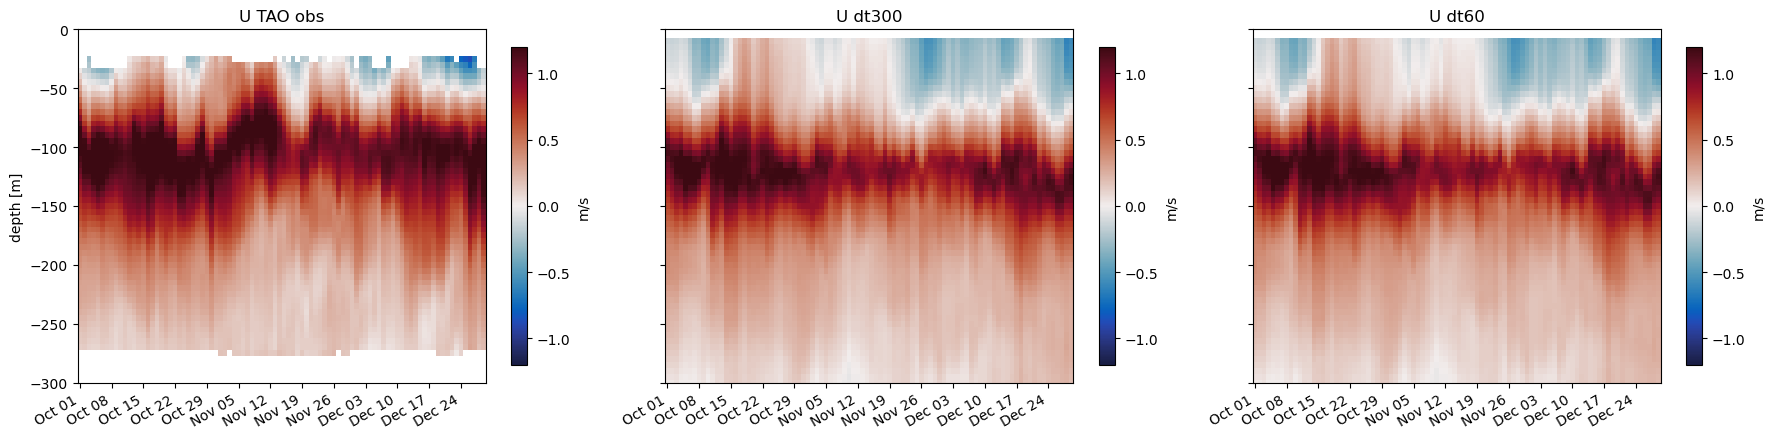

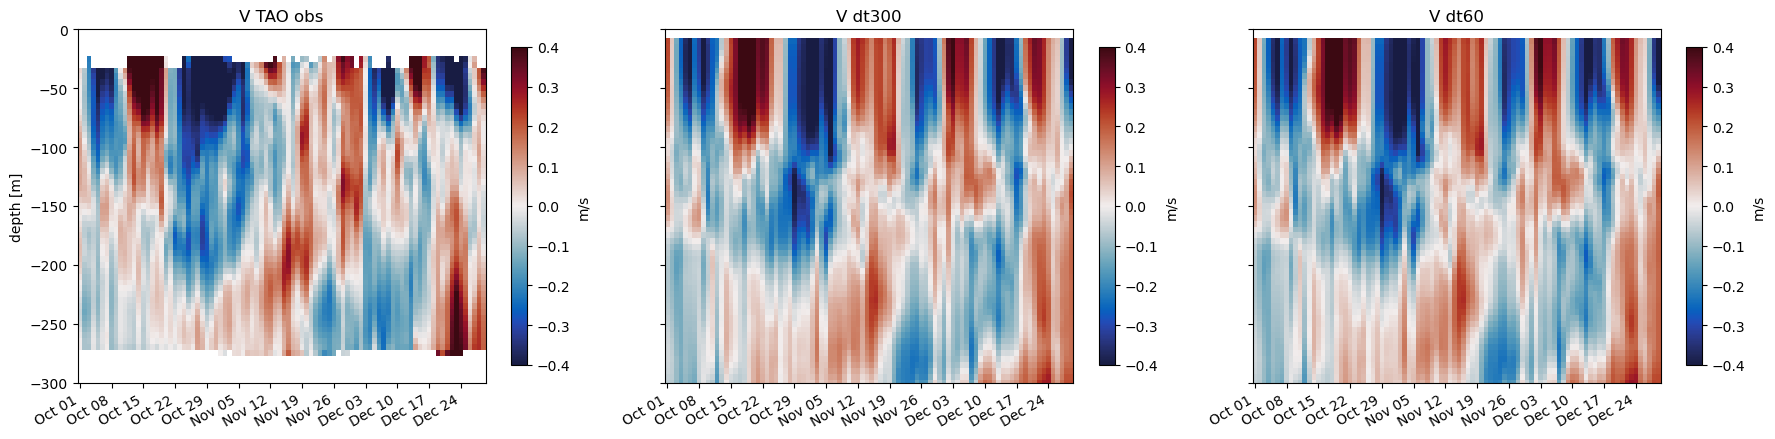

In [3]:
def hovm(ax, data, cmap, vmax, title):
    im = ax.pcolormesh(days, Z, data.T, cmap=cmap, vmin=-vmax, vmax=vmax, shading='auto')
    ax.set_ylim([-300, 0]); ax.set_title(title)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    plt.colorbar(im, ax=ax, shrink=.9, label='m/s')

for comp, vmax in (('U', 1.2), ('V', 0.4)):
    fig, ax = plt.subplots(1, 3, figsize=(18, 4.5), sharey=True)
    hovm(ax[0], obs[comp], cmo.balance, vmax, f'{comp} TAO obs')
    hovm(ax[1], model['dt300'][comp], cmo.balance, vmax, f'{comp} dt300')
    hovm(ax[2], model['dt60'][comp], cmo.balance, vmax, f'{comp} dt60')
    ax[0].set_ylabel('depth [m]')
    plt.tight_layout(); show()

## Time-mean profiles (Oct-Dec 2012)

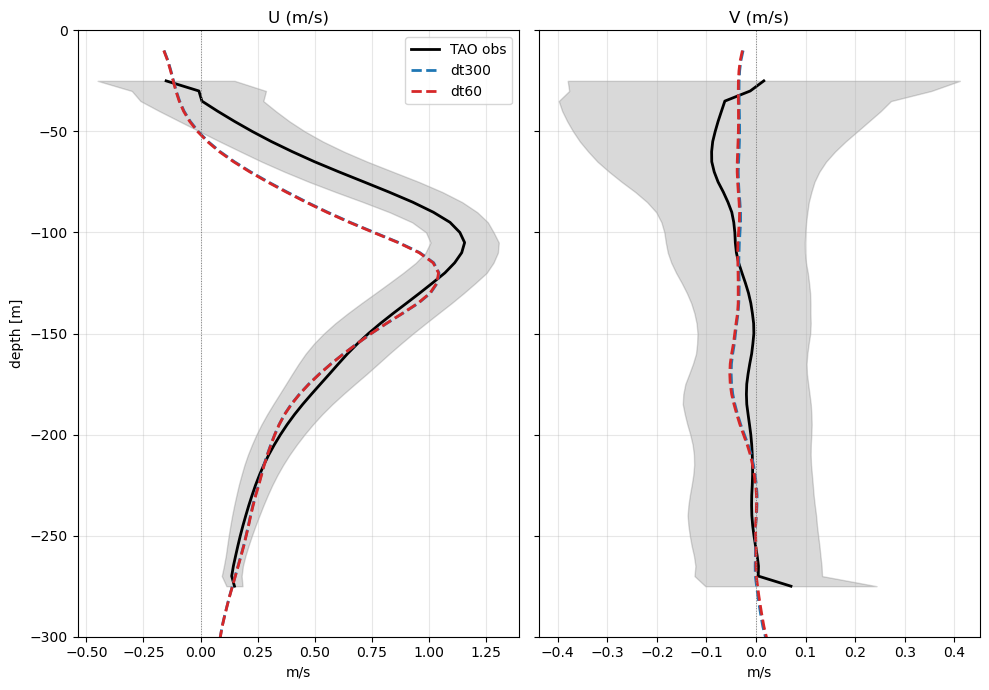

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(10, 7), sharey=True)
for k, comp in enumerate(('U', 'V')):
    om = np.nanmean(obs[comp], axis=0); osd = np.nanstd(obs[comp], axis=0)
    ax[k].plot(om, Z, 'k', lw=2, label='TAO obs')
    ax[k].fill_betweenx(Z, om-osd, om+osd, color='k', alpha=.15)
    for r in RUNS:
        ax[k].plot(np.nanmean(model[r][comp], axis=0), Z, color=COL[r], lw=2, ls='--', label=r)
    ax[k].axvline(0, color='0.5', lw=.7, ls=':')
    ax[k].set(title=f'{comp} (m/s)', xlabel='m/s', ylim=(-300, 0)); ax[k].grid(alpha=.3)
ax[0].set_ylabel('depth [m]'); ax[0].legend()
plt.tight_layout(); show()

## Error vs depth and scalar skill (vs TAO, Oct-Dec 2012)

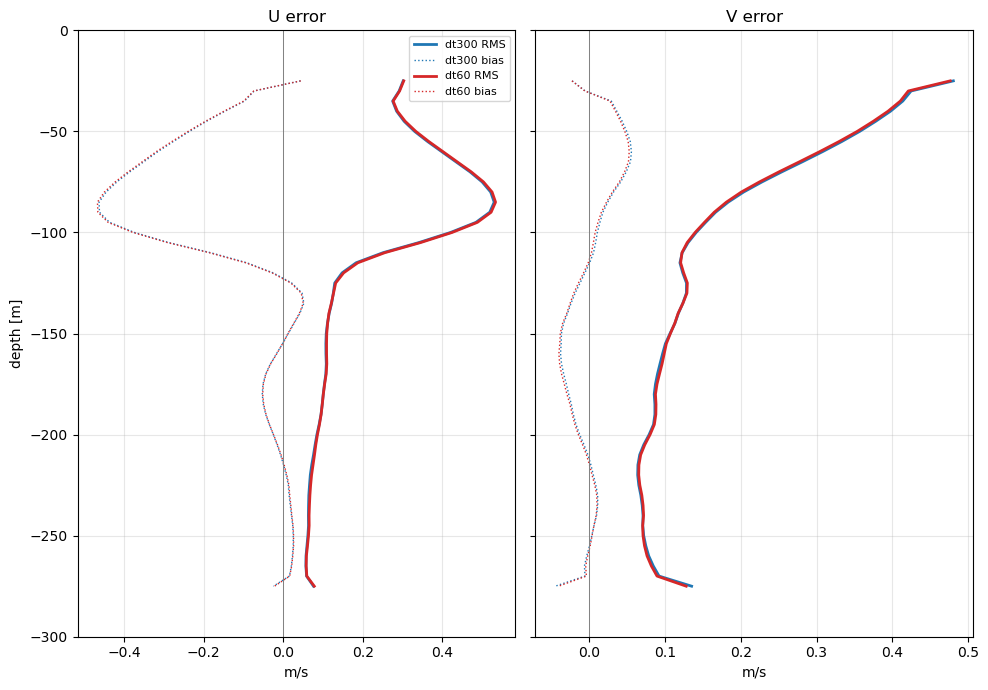

depth-avg (0-250 m) skill vs TAO, Oct-Dec 2012:
  U dt300  RMS=0.212  bias=-0.115 m/s
  U dt60   RMS=0.214  bias=-0.116 m/s
  U dt300-vs-dt60 RMS=0.0096 m/s
  V dt300  RMS=0.163  bias=+0.002 m/s
  V dt60   RMS=0.162  bias=+0.000 m/s
  V dt300-vs-dt60 RMS=0.0086 m/s


In [5]:
def stats(mod, ob):
    dif = mod - ob
    rmsp = np.sqrt(np.nanmean(dif**2, axis=0))
    biasp = np.nanmean(dif, axis=0)
    return rmsp, biasp

fig, ax = plt.subplots(1, 2, figsize=(10, 7), sharey=True)
for k, comp in enumerate(('U', 'V')):
    for r in RUNS:
        rmsp, biasp = stats(model[r][comp], obs[comp])
        ax[k].plot(rmsp, Z, color=COL[r], lw=2, label=f'{r} RMS')
        ax[k].plot(biasp, Z, color=COL[r], lw=1, ls=':', label=f'{r} bias')
    ax[k].axvline(0, color='0.5', lw=.7); ax[k].set(title=f'{comp} error', xlabel='m/s', ylim=(-300, 0))
    ax[k].grid(alpha=.3)
ax[0].set_ylabel('depth [m]'); ax[0].legend(fontsize=8)
plt.tight_layout(); show()

top = Z >= -250
print('depth-avg (0-250 m) skill vs TAO, Oct-Dec 2012:')
for comp in ('U', 'V'):
    for r in RUNS:
        rmsp, biasp = stats(model[r][comp], obs[comp])
        print(f'  {comp} {r:6s} RMS={np.nanmean(rmsp[top]):.3f}  bias={np.nanmean(biasp[top]):+.3f} m/s')
    d = model['dt300'][comp] - model['dt60'][comp]
    print(f'  {comp} dt300-vs-dt60 RMS={np.sqrt(np.nanmean(d[:, top]**2)):.4f} m/s')